# Figures from the SQL results
**Purpose:** the README figures for the revenue, retention and delivery questions (Figures Checklist 2, 3, 4, 8, 11).
**Input:** CSVs exported by `SQL/99_export_tables.sql` (`order_base.csv`, `item_base.csv`, `cohort_retention.csv`, `delivery_orders.csv`). All numbers come from the SQL views - this notebook only draws them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.3f}".format)

RAW = Path("../data/raw")
TABLES = Path("../reports/tables")
FIGS = Path("../reports/figures")
TABLES.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

In [2]:
# Chart style: recessive grid/axes, thin marks, text in neutral ink (never series colour)
BLUE, ORANGE = "#2a78d6", "#eb6834"      # on-time / main series = blue, late = orange (validated pair)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e5e4e0"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2, "legend.frameon": False,
    "font.size": 10,
})

def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight")
    print("saved", FIGS / name)

In [3]:
# PostgreSQL writes booleans as t / f -> tell pandas
BOOL = dict(true_values=["t"], false_values=["f"])
ob = pd.read_csv(TABLES / "order_base.csv", parse_dates=["purchase_month"], **BOOL)
ib = pd.read_csv(TABLES / "item_base.csv", parse_dates=["purchase_month"], **BOOL)
cohort = pd.read_csv(TABLES / "cohort_retention.csv", parse_dates=["cohort_month"])
dl = pd.read_csv(TABLES / "delivery_orders.csv", **BOOL)
kpi = ob[ob["in_kpi_period"]]
monthly = kpi.groupby("purchase_month").agg(orders=("order_id", "nunique"), revenue=("revenue", "sum"))
monthly["aov"] = monthly["revenue"] / monthly["orders"]
monthly.tail()

,orders,revenue,aov
purchase_month,,,
2018-04-01,6798,"1,133,264.960",166.706
2018-05-01,6749,"1,129,246.120",167.321
2018-06-01,6099,"1,012,202.490",165.962
2018-07-01,6159,"1,027,840.540",166.884
2018-08-01,6351,"985,558.160",155.182


## Figure 2 - Monthly revenue (R1)

saved ../reports/figures/rev_monthly_trend.png


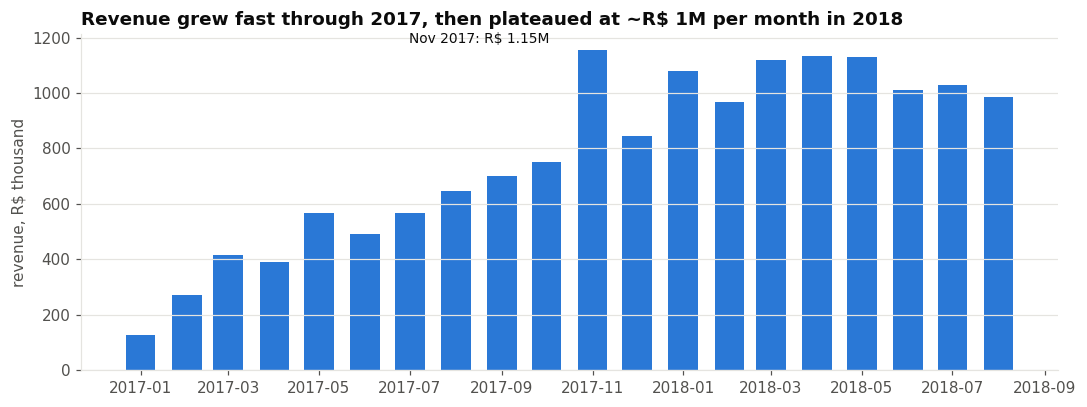

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(monthly.index, monthly["revenue"] / 1e3, width=20, color=BLUE)
peak = monthly["revenue"].idxmax()
ax.annotate(f"{peak:%b %Y}: R$ {monthly.loc[peak, 'revenue']/1e6:.2f}M", (peak, monthly.loc[peak, "revenue"] / 1e3),
            xytext=(-120, 5), textcoords="offset points", fontsize=9, color=INK)
ax.set_ylabel("revenue, R$ thousand")
ax.grid(axis="x", visible=False)
ax.set_title("Revenue grew fast through 2017, then plateaued at ~R$ 1M per month in 2018")
fig.tight_layout()
save(fig, "rev_monthly_trend.png")

## Figure 3 - Orders vs AOV (R2, R3)
Two panels with their own axes instead of one dual-axis chart: orders and AOV have different units.

saved ../reports/figures/rev_orders_vs_aov.png
orders: min 750 max 7289 | AOV: min 146.25 max 169.98


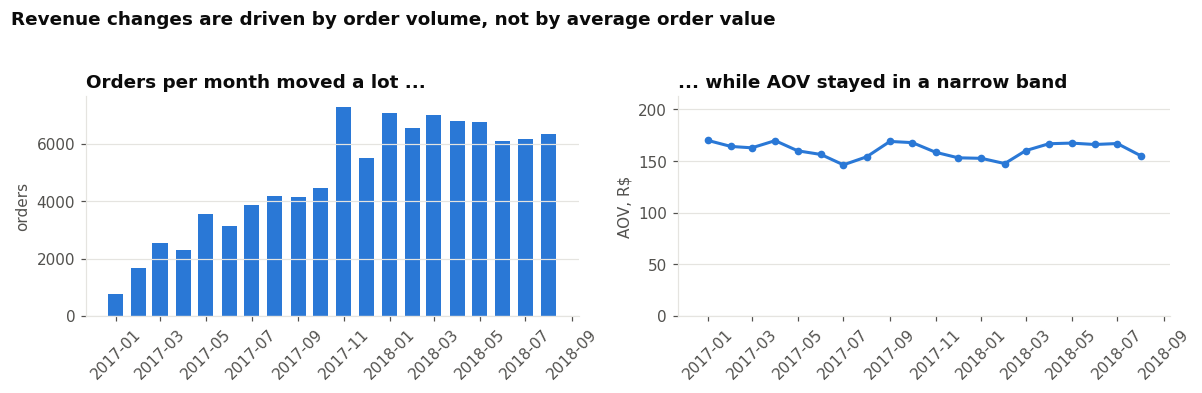

In [5]:
idx = monthly / monthly.iloc[0] * 100      # index: Jan 2017 = 100
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
axes[0].bar(monthly.index, monthly["orders"], width=20, color=BLUE)
axes[0].set_title("Orders per month moved a lot ...")
axes[0].set_ylabel("orders")
axes[1].plot(monthly.index, monthly["aov"], color=BLUE, linewidth=2, marker="o", markersize=4)
axes[1].set_ylim(0, monthly["aov"].max() * 1.25)
axes[1].set_title("... while AOV stayed in a narrow band")
axes[1].set_ylabel("AOV, R$")
for a in axes:
    a.grid(axis="x", visible=False)
    a.tick_params(axis="x", rotation=45)
fig.suptitle("Revenue changes are driven by order volume, not by average order value",
             x=0.01, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save(fig, "rev_orders_vs_aov.png")
print("orders: min", monthly["orders"].min(), "max", monthly["orders"].max(),
      "| AOV: min", round(monthly["aov"].min(), 2), "max", round(monthly["aov"].max(), 2))

## Figure 4 - Revenue by category, top 10 (R4)

saved ../reports/figures/rev_top_categories.png


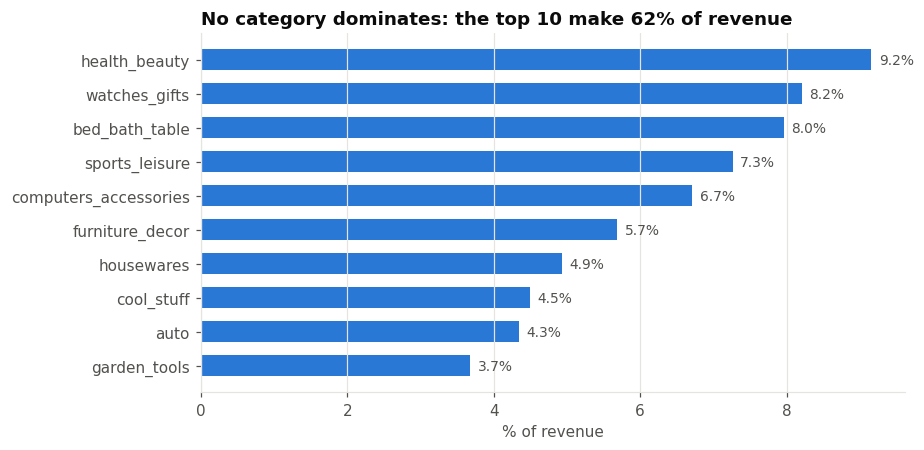

In [6]:
cat = ib[ib["in_kpi_period"]].groupby("category")["item_revenue"].sum().sort_values(ascending=False)
share = 100 * cat / cat.sum()
top = share.head(10)[::-1]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.barh(top.index, top.values, color=BLUE, height=0.6)
for i, v in enumerate(top.values):
    ax.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=9, color=INK2)
ax.set_xlabel("% of revenue")
ax.grid(axis="y", visible=False)
ax.set_title(f"No category dominates: the top 10 make {share.head(10).sum():.0f}% of revenue")
fig.tight_layout()
save(fig, "rev_top_categories.png")

## Figure 8 - Cohort retention heatmap (C1, C3)

saved ../reports/figures/ret_cohort_heatmap.png


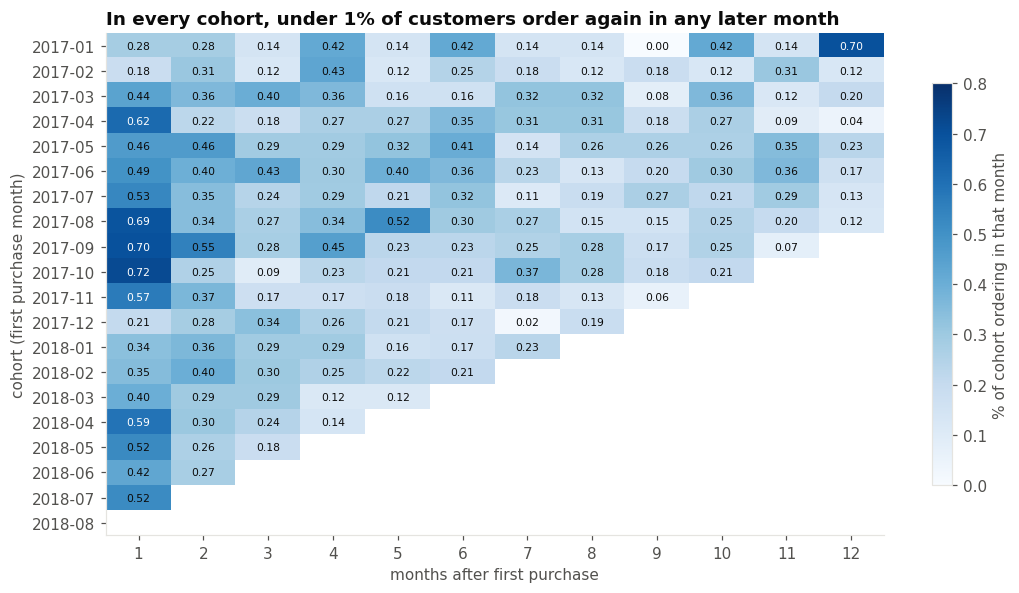

In [7]:
matrix = cohort.pivot(index="cohort_month", columns="month_number", values="retention_pct")
last_month = pd.Timestamp("2018-08-01")
for cm in matrix.index:                       # observable but empty cells = 0, unobservable = NaN
    for k in matrix.columns:
        observable = cm + pd.DateOffset(months=int(k)) <= last_month
        if observable and pd.isna(matrix.loc[cm, k]):
            matrix.loc[cm, k] = 0
        if not observable:
            matrix.loc[cm, k] = np.nan
m = matrix.loc[:, 1:12]                       # month 0 is 100% by definition
fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(m.values, cmap="Blues", aspect="auto", vmin=0, vmax=0.8)
ax.set_xticks(range(m.shape[1]), m.columns)
ax.set_yticks(range(m.shape[0]), [d.strftime("%Y-%m") for d in m.index])
ax.set_xlabel("months after first purchase")
ax.set_ylabel("cohort (first purchase month)")
ax.grid(False)
for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        v = m.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if v > 0.55 else INK)
cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.set_label("% of cohort ordering in that month")
ax.set_title("In every cohort, under 1% of customers order again in any later month")
fig.tight_layout()
save(fig, "ret_cohort_heatmap.png")

## Figure 11 - Late % by state (D2)

saved ../reports/figures/del_late_rate_by_state.png


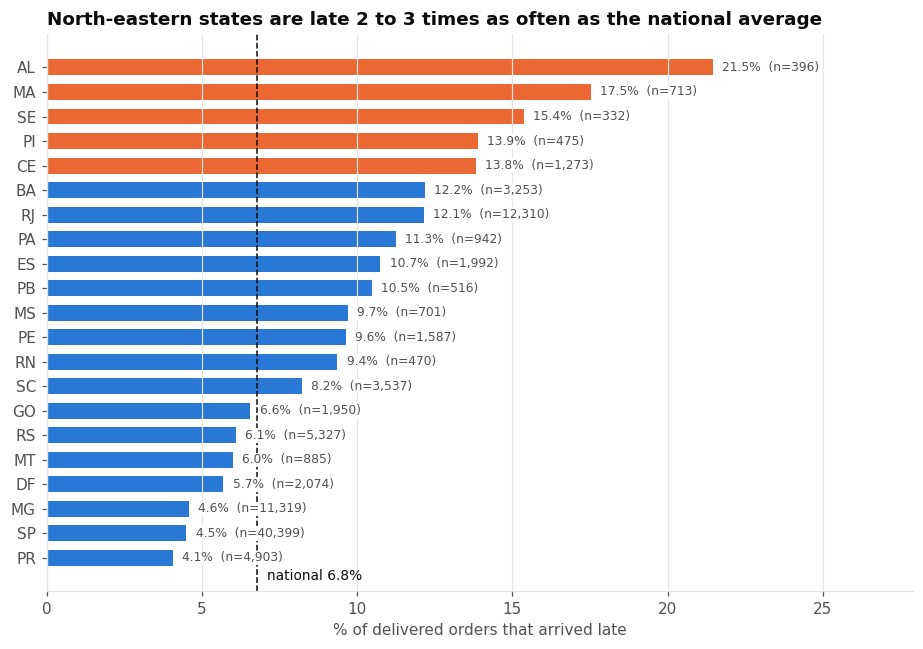

In [8]:
st = dl.groupby("customer_state").agg(orders=("order_id", "size"), late=("is_late", "mean"))
st = st[st["orders"] >= 300].sort_values("late")
national = 100 * dl["is_late"].mean()
fig, ax = plt.subplots(figsize=(8.5, 6))
colors = [ORANGE if v * 100 > 2 * national else BLUE for v in st["late"]]
ax.barh(st.index, 100 * st["late"], color=colors, height=0.65)
ax.axvline(national, color=INK, linestyle="--", linewidth=1, zorder=1)
ax.text(national + 0.3, -0.9, f"national {national:.1f}%", fontsize=9, color=INK)
for i, (v, n) in enumerate(zip(st["late"], st["orders"])):
    ax.text(100 * v + 0.3, i, f"{100*v:.1f}%  (n={n:,})", va="center", fontsize=8, color=INK2,
            bbox=dict(facecolor="white", edgecolor="none", pad=0.5), zorder=3)
ax.set_xlabel("% of delivered orders that arrived late")
ax.grid(axis="y", visible=False)
ax.set_title("North-eastern states are late 2 to 3 times as often as the national average")
ax.set_xlim(0, 100 * st["late"].max() * 1.3)
fig.tight_layout()
save(fig, "del_late_rate_by_state.png")